# Kalshi Fed funds rate contracts

Market-implied fed funds target (upper bound) after each FOMC meeting, built from Kalshi's `KXFED` series (including the legacy `FED-*` events).

Each meeting is an event with a ladder of binary contracts: *"Will the upper bound of the federal funds rate be above X% following the meeting?"* A contract's price is the market's P(rate > X). Differencing across the ladder gives a probability for each 25bp outcome, and the expected upper bound is the probability-weighted sum.

**Running it.** Run all cells. The first run downloads everything from Kalshi's public API (no key needed, about 3 minutes) and caches it in `data/`. Later runs read the cache unless you set `REFRESH = True`. It works locally, in JupyterLab, VS Code, or Colab.

API reference: https://docs.kalshi.com/openapi.yaml

In [1]:
# Colab and most Jupyter installs already have these; uncomment if not.
# %pip install pandas matplotlib openpyxl pypdf

import io, json, os, ssl, time, urllib.error, urllib.parse, urllib.request
from datetime import datetime, timedelta
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

REFRESH = False        # True: re-download from Kalshi even if data/ exists
INTERVAL = 1440        # candle size in minutes: 1, 60 or 1440 (daily)
SERIES = "KXFED"
BASE = "https://api.elections.kalshi.com/trade-api/v2"
DATA = Path("data"); DATA.mkdir(exist_ok=True)
STEP = 0.25            # FOMC moves in 25bp increments

## 1. Download markets and daily candlesticks

Markets that settled before Kalshi's historical cutoff are only served by the `/historical/...` endpoints, so both live and historical endpoints are queried. Historical candles use bare field names (`close`, `volume`) where live ones use `close_dollars`, `volume_fp`.

In [2]:
# python.org builds on macOS ship without CA certs; fall back to the system bundle.
try:
    import certifi
    SSL_CTX = ssl.create_default_context(cafile=certifi.where())
except ImportError:
    SSL_CTX = ssl.create_default_context(
        cafile="/etc/ssl/cert.pem" if os.path.exists("/etc/ssl/cert.pem") else None)


def get(path, params=None, retries=5):
    url = f"{BASE}{path}" + ("?" + urllib.parse.urlencode(params) if params else "")
    for attempt in range(retries):
        try:
            with urllib.request.urlopen(url, timeout=30, context=SSL_CTX) as r:
                time.sleep(0.08)  # stay well under the public rate limit
                return json.load(r)
        except urllib.error.HTTPError as e:
            if e.code == 404:
                return None
            if e.code == 429 or e.code >= 500:
                time.sleep(2 ** attempt); continue
            raise
        except urllib.error.URLError:
            time.sleep(2 ** attempt)
    raise RuntimeError(f"failed: {url}")


def paginate(path, key, params):
    out, cursor = [], None
    while True:
        d = get(path, dict(params, limit=200, **({"cursor": cursor} if cursor else {}))) or {}
        out += d.get(key, [])
        cursor = d.get("cursor")
        if not cursor:
            return out


to_ts = lambda iso: int(datetime.fromisoformat(iso.replace("Z", "+00:00")).timestamp())
num = lambda x: None if x in (None, "") else float(x)
ohlc = lambda d, f: num((d or {}).get(f"{f}_dollars", (d or {}).get(f)))


def fetch_candles(m, historical):
    start, end = to_ts(m["open_time"]), to_ts(m["close_time"]) + 86400
    path = (f"/historical/markets/{m['ticker']}/candlesticks" if historical
            else f"/series/{SERIES}/markets/{m['ticker']}/candlesticks")
    rows, chunk = [], 5000 * INTERVAL * 60 // 2
    for s in range(start, end, chunk):
        d = get(path, {"start_ts": s, "end_ts": min(s + chunk, end), "period_interval": INTERVAL})
        for c in (d or {}).get("candlesticks", []):
            rows.append({"ticker": m["ticker"], "ts": c["end_period_ts"],
                         "yes_bid": ohlc(c.get("yes_bid"), "close"),
                         "yes_ask": ohlc(c.get("yes_ask"), "close"),
                         "last": ohlc(c.get("price"), "close"),
                         "volume": num(c.get("volume_fp", c.get("volume"))),
                         "open_interest": num(c.get("open_interest_fp", c.get("open_interest")))})
    return rows


def download():
    events = paginate("/events", "events", {"series_ticker": SERIES})
    print(f"{len(events)} events in {SERIES}")
    mrows, crows = [], []
    for e in sorted(events, key=lambda e: e["event_ticker"]):
        et = e["event_ticker"]
        live = paginate("/markets", "markets", {"event_ticker": et})
        hist = paginate("/historical/markets", "markets", {"event_ticker": et})
        for historical, ms in ((False, live), (True, hist)):
            for m in ms:
                strike = m.get("floor_strike")
                if strike is None:  # oldest markets: parse from ticker "...-T0.25"
                    strike = float(m["ticker"].rsplit("-T", 1)[-1])
                mrows.append({"ticker": m["ticker"], "event_ticker": et, "event_title": e["title"],
                              "meeting_date": m["close_time"][:10], "strike": float(strike),
                              "status": m["status"], "result": m.get("result"),
                              "open_time": m["open_time"], "close_time": m["close_time"],
                              "volume": num(m.get("volume_fp")), "historical": historical,
                              "title": m.get("title")})
                crows += fetch_candles(m, historical)
        print(f"  {et}: {len(live)} live + {len(hist)} historical markets")
    markets = pd.DataFrame(mrows).sort_values(["meeting_date", "strike"])
    candles = pd.DataFrame(crows)
    candles["datetime"] = pd.to_datetime(candles.ts, unit="s", utc=True)
    # Daily candles end at midnight ET; label each by the ET day it covers.
    candles["date"] = (pd.to_datetime(candles.ts - 1, unit="s", utc=True)
                       .dt.tz_convert("America/New_York").dt.date.astype(str)
                       if INTERVAL == 1440 else candles.datetime.astype(str))
    candles = candles.merge(markets[["ticker", "event_ticker", "strike"]], on="ticker") \
                     .sort_values(["event_ticker", "strike", "ts"])
    markets.to_csv(DATA / "markets.csv", index=False)
    candles.to_csv(DATA / "candles_daily.csv", index=False)
    return markets, candles


if REFRESH or not (DATA / "candles_daily.csv").exists():
    markets, candles = download()
else:
    markets = pd.read_csv(DATA / "markets.csv")
    candles = pd.read_csv(DATA / "candles_daily.csv")
print(f"{markets.event_ticker.nunique()} meetings, {len(markets)} contracts, "
      f"{len(candles):,} candles, through {candles.date.max()}")

52 meetings, 660 contracts, 97,888 candles, through 2026-09-27


## 2. From contract prices to an implied rate

For each contract on each day:

- **Price.** Bid/ask midpoint when the spread is 20¢ or less. Up to 40¢, the last trade clipped into the quote. Wider than that, the strike is dropped for the day.
- **Quiet days.** Kalshi only emits a candle when something changes, so each contract's last quote is carried forward.
- **Monotonicity.** P(rate > k) must fall as k rises. A weighted isotonic fit (tighter quotes weigh more) enforces that without letting one stale print drag the whole ladder.
- **Reliability.** A meeting-day is flagged unreliable when more than 10% of probability sits beyond the usable strikes (as in 2022, when hikes outran the ladder) or in gaps wider than 50bp between them.

In [3]:
def daily_grid(candles, markets):
    close = markets.set_index("ticker").meeting_date
    asof, cols, out = candles.date.max(), ["yes_bid", "yes_ask", "last", "open_interest", "event_ticker", "strike"], []
    for t, g in candles.groupby("ticker"):
        g = g.drop_duplicates("date", keep="last").set_index("date")
        days = pd.date_range(g.index.min(), max(g.index.max(), min(close[t], asof)))
        g = g.reindex(days.strftime("%Y-%m-%d"))
        g[cols] = g[cols].ffill()
        g["volume"] = g.volume.fillna(0)
        g["ticker"] = t
        out.append(g.rename_axis("date").reset_index())
    return pd.concat(out)


def pava_decreasing(y, w):
    # Weighted isotonic regression: best non-increasing fit to y.
    blocks = []
    for yi, wi in zip(y, w):
        blocks.append([yi, wi, 1])
        while len(blocks) > 1 and blocks[-2][0] < blocks[-1][0]:
            v2, w2, n2 = blocks.pop(); v1, w1, n1 = blocks.pop()
            blocks.append([(v1 * w1 + v2 * w2) / (w1 + w2), w1 + w2, n1 + n2])
    return [v for v, _, n in blocks for _ in range(n)]


def implied(candles, markets):
    df = daily_grid(candles, markets).merge(markets[["ticker", "meeting_date"]], on="ticker")
    df = df[df.date <= df.meeting_date]
    spread = df.yes_ask - df.yes_bid
    mid = (df.yes_bid + df.yes_ask) / 2
    last = df["last"].clip(lower=df.yes_bid, upper=df.yes_ask)
    df["p_above"] = mid.where(spread.between(0, 0.20), last.where(spread.between(0, 0.40)))
    df["w"] = 1 / (spread.clip(lower=0).fillna(1) + 0.02)
    df = df.dropna(subset=["p_above"])

    out = []
    for (ev, date), g in df.groupby(["event_ticker", "date"]):
        g = g.sort_values("strike")
        k = g.strike.to_numpy()
        p = np.clip(pava_decreasing(g.p_above.to_numpy(), g.w.to_numpy()), 0, 1)
        # Buckets: <=k0, (k0,k1], ..., >k_last. A bucket spanning several 25bp
        # outcomes (a strike was missing that day) is valued at its midpoint.
        probs = {f"p_le_{k[0]:.2f}": 1 - p[0]}
        mean, wide = k[0] * (1 - p[0]), 0.0
        for i in range(len(k)):
            hi = p[i + 1] if i + 1 < len(k) else 0.0
            top = k[i + 1] if i + 1 < len(k) else k[i] + STEP
            mass = p[i] - hi
            probs[f"p_{top:.2f}"] = mass
            mean += (k[i] + STEP + top) / 2 * mass
            wide += mass if top - k[i] > 2 * STEP else 0
        lo_tail = 0.0 if k[0] <= 0.25 else 1 - p[0]   # below 0.25% is the zero lower bound
        hi_tail = p[-1]
        out.append({"event_ticker": ev, "meeting_date": g.meeting_date.iloc[0], "date": date,
                    "implied_upper_bound": round(mean, 4),
                    "most_likely": max(probs, key=probs.get).split("_")[-1],
                    "n_strikes": len(k), "tail_mass": round(lo_tail + hi_tail, 4),
                    "gap_mass": round(wide, 4),
                    "reliable": bool(lo_tail <= 0.10 and hi_tail <= 0.10 and wide <= 0.10),
                    "volume": g.volume.sum(), "open_interest": g.open_interest.sum(),
                    "distribution": json.dumps({a: round(b, 4) for a, b in probs.items()})})
    return pd.DataFrame(out).sort_values(["meeting_date", "date"])


rates = implied(candles, markets)
rates.to_csv(DATA / "implied_rate_daily.csv", index=False)
print(f"{len(rates):,} meeting-days, {rates.reliable.sum():,} reliable")
rates.tail()

12,916 meeting-days, 8,155 reliable


,event_ticker,meeting_date,date,implied_upper_bound,most_likely,n_strikes,tail_mass,gap_mass,reliable,volume,open_interest,distribution
12911,KXFED-28JAN,2028-01-26,2026-09-23,3.2742,3.50,14,0.6,0.0,False,0.0,210.0,"{""p_le_0.00"": 0.03, ""p_0.25"": 0.0, ""p_0.50"": 0..."
12912,KXFED-28JAN,2028-01-26,2026-09-24,3.3450,3.50,14,0.6,0.0,False,0.0,210.0,"{""p_le_0.00"": 0.01, ""p_0.25"": 0.0, ""p_0.50"": 0..."
12913,KXFED-28JAN,2028-01-26,2026-09-25,3.3675,3.50,14,0.6,0.0,False,0.0,210.0,"{""p_le_0.00"": 0.01, ""p_0.25"": 0.0, ""p_0.50"": 0..."
12914,KXFED-28JAN,2028-01-26,2026-09-26,3.3675,3.50,14,0.6,0.0,False,0.0,210.0,"{""p_le_0.00"": 0.01, ""p_0.25"": 0.0, ""p_0.50"": 0..."
12915,KXFED-28JAN,2028-01-26,2026-09-27,3.3675,3.50,14,0.6,0.0,False,0.0,210.0,"{""p_le_0.00"": 0.01, ""p_0.25"": 0.0, ""p_0.50"": 0..."


## 3. Implied effective fed funds rate (EFFR)

Kalshi settles on the **upper bound** of the target range. Fed funds futures, and most of the rates literature, use the **effective** rate (EFFR): the volume-weighted rate banks actually pay, which trades inside the range. To put Kalshi on the same basis, add the recent gap between EFFR and the upper bound:

`implied_effr = implied_upper_bound + (EFFR − upper bound)`

The gap is the median of the last 20 published days as of each date, so it only uses information available then. It was about −17bp from 2021 to 2024 and narrowed to about −12bp in 2026 as bank reserves got scarcer. Both series come from FRED (`EFFR`, `DFEDTARU`), which is free with no key. The gap is assumed to stay where it is through the forecast horizon.

In [4]:
def fred(series):
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series}&cosd=2021-01-01"
    with urllib.request.urlopen(url, timeout=30, context=SSL_CTX) as resp:
        d = pd.read_csv(io.StringIO(resp.read().decode()))
    d.columns = ["date", series]
    d[series] = pd.to_numeric(d[series], errors="coerce")
    return d


fred_path = DATA / "fred_effr.csv"
if REFRESH or not fred_path.exists():
    fred("EFFR").merge(fred("DFEDTARU"), on="date", how="outer").sort_values("date").to_csv(fred_path, index=False)
fr = pd.read_csv(fred_path)
fr["gap"] = fr.EFFR - fr.DFEDTARU
all_days = pd.date_range(fr.date.min(), max(fr.date.max(), rates.date.max())).strftime("%Y-%m-%d")
gap = fr.dropna(subset=["gap"]).set_index("date").gap.rolling(20, min_periods=5).median().reindex(all_days).ffill()
effr = fr.set_index("date").EFFR.reindex(all_days)

rates["effr_spread"] = rates.date.map(gap).round(4)
rates["implied_effr"] = (rates.implied_upper_bound + rates.effr_spread).round(4)
rates.to_csv(DATA / "implied_rate_daily.csv", index=False)

print("EFFR minus upper bound, by year (bp):")
print((fr.assign(yr=fr.date.str[:4]).groupby("yr").gap.mean() * 100).round(1).to_string())
rates[["event_ticker", "date", "implied_upper_bound", "effr_spread", "implied_effr"]].tail()

EFFR minus upper bound, by year (bp):
yr
2021   -17.1
2022   -17.0
2023   -17.1
2024   -17.0
2025   -15.9
2026   -11.7


,event_ticker,date,implied_upper_bound,effr_spread,implied_effr
12911,KXFED-28JAN,2026-09-23,3.2742,-0.12,3.1542
12912,KXFED-28JAN,2026-09-24,3.3450,-0.12,3.2250
12913,KXFED-28JAN,2026-09-25,3.3675,-0.12,3.2475
12914,KXFED-28JAN,2026-09-26,3.3675,-0.12,3.2475
12915,KXFED-28JAN,2026-09-27,3.3675,-0.12,3.2475


## 4. Realized decisions, scorecard, and constant-horizon series

The realized upper bound comes from how each ladder settled. The scorecard compares it with the implied rate on the last day before the meeting. The constant-horizon series tracks, each day, the implied rate (upper bound and EFFR basis) for the next, 3rd and 6th upcoming meeting (reliable days only), alongside the target in force and the actual EFFR.

In [5]:
settled = markets[markets.result.isin(["yes", "no"])]
realized = (settled.groupby(["event_ticker", "meeting_date"])
            .apply(lambda g: g[g.result == "yes"].strike.max() + STEP if (g.result == "yes").any()
                   else g.strike.min(), include_groups=False)
            .rename("upper_bound").reset_index().sort_values("meeting_date"))

pre = rates[rates.date < rates.meeting_date].groupby("event_ticker").tail(1)
scorecard = (pre[["event_ticker", "meeting_date", "date", "implied_upper_bound"]]
             .merge(realized[["event_ticker", "upper_bound"]], on="event_ticker")
             .rename(columns={"date": "last_quote_date", "upper_bound": "realized"})
             .sort_values("meeting_date"))
scorecard["change_bp"] = (scorecard.realized.diff() * 100).round()
scorecard["error_bp"] = ((scorecard.implied_upper_bound - scorecard.realized) * 100).round(1)

meeting_dates = sorted(rates.meeting_date.unique())
lookup = rates[rates.reliable].set_index(["meeting_date", "date"]).implied_upper_bound
rows = []
for d in sorted(rates.date.unique()):
    upcoming = [x for x in meeting_dates if x >= d]
    past = realized[realized.meeting_date < d]
    row = {"date": d, "current_target": past.upper_bound.iloc[-1] if len(past) else np.nan,
           "effr": effr.get(d), "effr_spread": gap.get(d)}
    for name, i in (("next", 0), ("third", 2), ("sixth", 5)):
        mt = upcoming[i] if i < len(upcoming) else None
        row[f"{name}_meeting"] = mt
        row[f"{name}_implied"] = lookup.get((mt, d), np.nan) if mt else np.nan
        row[f"{name}_implied_effr"] = row[f"{name}_implied"] + gap.get(d, np.nan)
    rows.append(row)
horizon = pd.DataFrame(rows)
horizon["date"] = pd.to_datetime(horizon.date)

realized.to_csv(DATA / "realized_target.csv", index=False)
scorecard.to_csv(DATA / "meeting_summary.csv", index=False)
horizon.to_csv(DATA / "constant_horizon.csv", index=False)

err = scorecard.error_bp.abs()
print(f"Day-before implied vs realized, {len(scorecard)} meetings: "
      f"median |error| {err.median():.1f}bp, mean {err.mean():.1f}bp, max {err.max():.1f}bp")

Day-before implied vs realized, 41 meetings: median |error| 0.6bp, mean 1.3bp, max 10.5bp


## 5. Where things stand today

In [6]:
asof = rates.date.max()
target = realized[realized.meeting_date <= asof].iloc[-1]
nxt = rates[(rates.meeting_date >= asof) & (rates.date == asof)].iloc[0]
dist = json.loads(nxt.distribution)
T = target.upper_bound
val = lambda key: float(key.split("_")[-1])
hike = sum(v for k, v in dist.items() if val(k) > T + 1e-9)
cut = sum(v for k, v in dist.items() if val(k) < T - 1e-9)
print(f"As of {asof}")
print(f"  Target upper bound: {T:.2f}% (set {target.meeting_date})")
print(f"  Actual EFFR: {fr.dropna(subset=['EFFR']).EFFR.iloc[-1]:.2f}% ({fr.dropna(subset=['EFFR']).date.iloc[-1]})")
print(f"  Next meeting {nxt.meeting_date}: implied {nxt.implied_upper_bound:.3f}% upper bound, {nxt.implied_effr:.3f}% EFFR  "
      f"| hike {hike:.0%}  hold {1 - hike - cut:.0%}  cut {cut:.0%}")

As of 2026-09-27
  Target upper bound: 4.00% (set 2026-09-16)
  Actual EFFR: 3.88% (2026-09-25)
  Next meeting 2026-10-28: implied 4.164% upper bound, 4.044% EFFR  | hike 64%  hold 35%  cut 1%


In [7]:
# Shared chart style: thin lines, recessive grid, colorblind-validated palette.
C = {"s1": "#2a78d6", "s2": "#eb6834", "s3": "#1baf7a", "ink": "#11151c", "ink2": "#4a5160", "grid": "#e3e6ec"}
plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (11, 4.6), "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False, "axes.spines.left": False,
    "axes.edgecolor": C["grid"], "axes.grid": True, "axes.grid.axis": "y",
    "grid.color": C["grid"], "grid.linewidth": 0.8, "axes.axisbelow": True,
    "axes.labelcolor": C["ink2"], "xtick.color": C["ink2"], "ytick.color": C["ink2"],
    "ytick.left": False, "axes.titleweight": "bold", "axes.titlesize": 13,
    "axes.titlelocation": "left", "legend.frameon": False, "lines.linewidth": 2,
})
pct = plt.FuncFormatter(lambda v, _: f"{v:.2f}%")

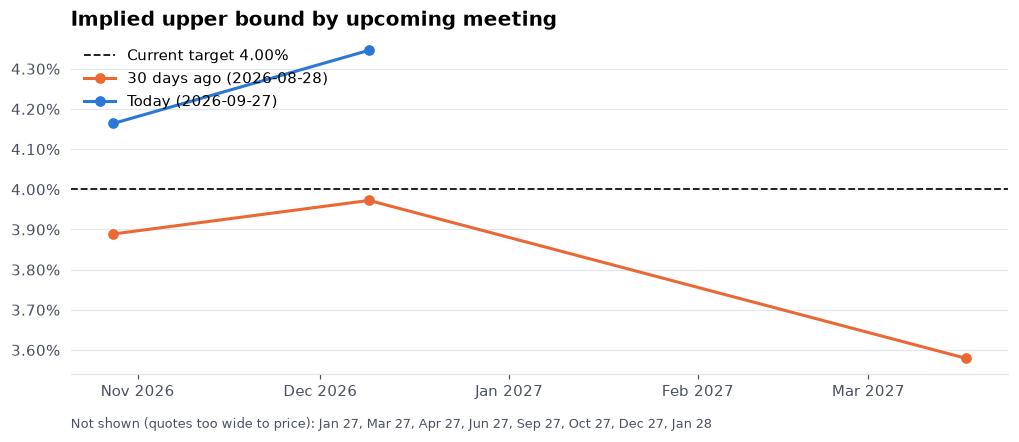

In [8]:
def path_on(date):
    d = rates[(rates.meeting_date >= asof) & (rates.date == date) & rates.reliable]
    return pd.to_datetime(d.meeting_date), d.implied_upper_bound

month_ago = (pd.Timestamp(asof) - timedelta(days=30)).strftime("%Y-%m-%d")
fig, ax = plt.subplots(figsize=(11, 4))
ax.axhline(T, color=C["ink"], lw=1.2, ls="--", label=f"Current target {T:.2f}%")
ax.plot(*path_on(month_ago), marker="o", color=C["s2"], label=f"30 days ago ({month_ago})")  # lines join priced meetings only
ax.plot(*path_on(asof), marker="o", color=C["s1"], label=f"Today ({asof})")
ax.yaxis.set_major_formatter(pct)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.set_title("Implied upper bound by upcoming meeting")
ax.legend(loc="upper left")
skipped = rates[(rates.meeting_date >= asof) & (rates.date == asof) & ~rates.reliable].meeting_date
if len(skipped):
    ax.annotate("Not shown (quotes too wide to price): " + ", ".join(pd.to_datetime(skipped).dt.strftime("%b %y")),
                (0, -0.16), xycoords="axes fraction", fontsize=8.5, color=C["ink2"])
plt.show()

### Odds by meeting

Each bar is one possible decision, and its height is the market's probability: the ladder differenced into outcomes. For the upcoming meeting it compares today with 30 days ago. For a past meeting it shows 1 month, 1 week and 1 day before, with the actual decision shaded. The hold / ±bp labels are measured from the target in force going into that meeting.

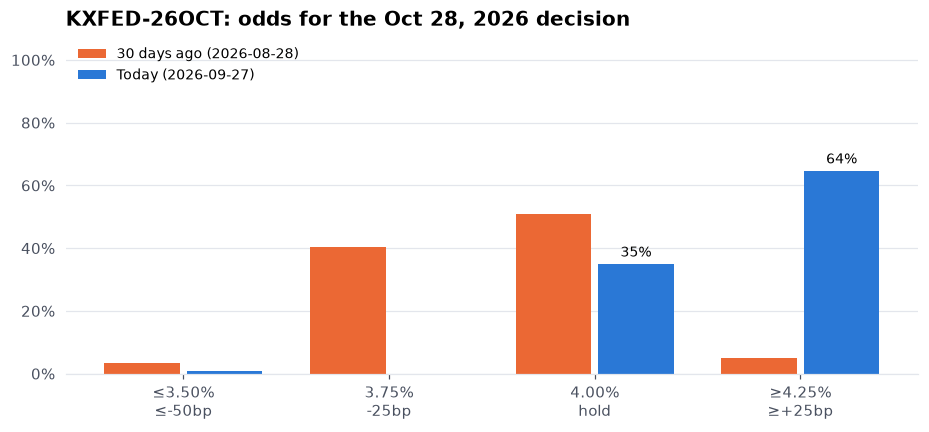

In [9]:
def on_grid(d):
    # Spread each bucket's mass evenly over the 25bp outcomes it spans, so days
    # with missing strikes share one set of outcomes.
    out, prev = {}, None
    for k, v in d.items():
        x = float(k.split("_")[-1])
        pts = [x] if k.startswith("p_le") else [round(prev + STEP * (i + 1), 2) for i in range(max(1, round((x - prev) / STEP)))]
        for q in pts:
            out[q] = out.get(q, 0) + v / len(pts)
        prev = x
    return out


def odds_on_or_before(meeting, date):
    g = rates[(rates.event_ticker == meeting) & (rates.date <= date)]
    return (g.date.iloc[-1], on_grid(json.loads(g.distribution.iloc[-1]))) if len(g) else (None, {})


def odds_chart(meeting):
    info = rates[rates.event_ticker == meeting].iloc[0]
    mdate = info.meeting_date
    real = realized.loc[realized.event_ticker == meeting, "upper_bound"]
    real = real.iloc[0] if len(real) else None
    prior = realized[realized.meeting_date < mdate]
    T0 = prior.upper_bound.iloc[-1] if len(prior) else T
    shift = lambda n: (pd.Timestamp(mdate) - pd.Timedelta(days=n)).strftime("%Y-%m-%d")
    snaps = ([("1 month before", shift(30), C["s2"]), ("1 week before", shift(7), C["s3"]), ("1 day before", shift(1), C["s1"])]
             if real is not None else [("30 days ago", month_ago, C["s2"]), ("Today", asof, C["s1"])])
    series = [(f"{lab} ({d})", dist, col) for lab, day, col in snaps for d, dist in [odds_on_or_before(meeting, day)] if d]
    # Contiguous range of outcomes reaching 2% (plus the actual one); fold the tails into the end bars.
    grid_all = sorted(set().union(*[set(d) for _, d, _ in series]))
    big = [k for k in grid_all if max(d.get(k, 0) for _, d, _ in series) >= 0.02] + ([real] if real is not None else [])
    outcomes = [k for k in grid_all if min(big) <= k <= max(big)]
    fold = lambda d: [sum(v for k, v in d.items() if k <= outcomes[0])] + [d.get(k, 0) for k in outcomes[1:-1]] + \
                     [sum(v for k, v in d.items() if k >= outcomes[-1])]
    x, n = np.arange(len(outcomes)), len(series)
    w = 0.8 / n
    fig, ax = plt.subplots(figsize=(10, 4))
    if real is not None and real in outcomes:
        ax.axvspan(outcomes.index(real) - 0.46, outcomes.index(real) + 0.46, color=C["grid"], zorder=0)
        ax.annotate("Actual", (outcomes.index(real), 1.0), ha="center", va="bottom", fontsize=9, fontweight="bold")
    for i, (lab, dist, col) in enumerate(series):
        vals = fold(dist)
        bars = ax.bar(x - 0.4 + w * (i + 0.5), vals, w * 0.92, color=col, label=lab)
        if i == n - 1:
            for b, v in zip(bars, vals):
                if v >= 0.02:
                    ax.annotate(f"{v:.0%}", (b.get_x() + b.get_width() / 2, v), ha="center", va="bottom",
                                xytext=(0, 3), textcoords="offset points", fontsize=9)
    tag = lambda k: "hold" if abs(k - T0) < 1e-9 else f"+{(k - T0) * 100:.0f}bp" if k > T0 else f"{(k - T0) * 100:.0f}bp"
    edge = lambda i: "≤" if i == 0 and outcomes[0] > grid_all[0] else "≥" if i == len(outcomes) - 1 and outcomes[-1] < grid_all[-1] else ""
    ax.set_xticks(x, [f"{edge(i)}{k:.2f}%\n{edge(i)}{tag(k)}" for i, k in enumerate(outcomes)])
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.set_ylim(0, 1.08)
    mt = pd.Timestamp(mdate)
    ax.set_title(f"{meeting}: odds for the {mt:%b} {mt.day}, {mt.year} decision" + (f" (set {real:.2f}%)" if real is not None else ""))
    ax.legend(loc="upper left", fontsize=9)
    plt.show()


odds_chart(nxt.event_ticker)

Two past meetings where the market was caught out. **June 2022**: a week before, it gave the 75bp hike 5%; after press reports days before the meeting, 81% the day before. **September 2024**: 5% on the 50bp cut a week before, 54% the day before. Call `odds_chart("FED-23MAR")` or any other event ticker to look at others.

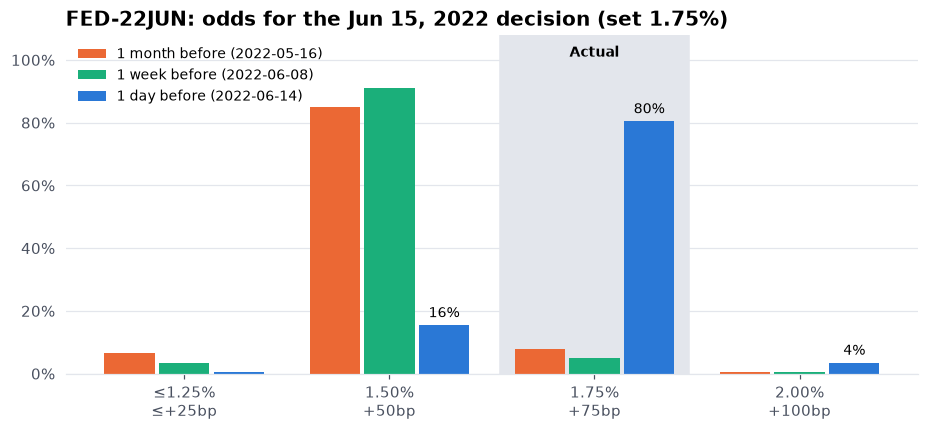

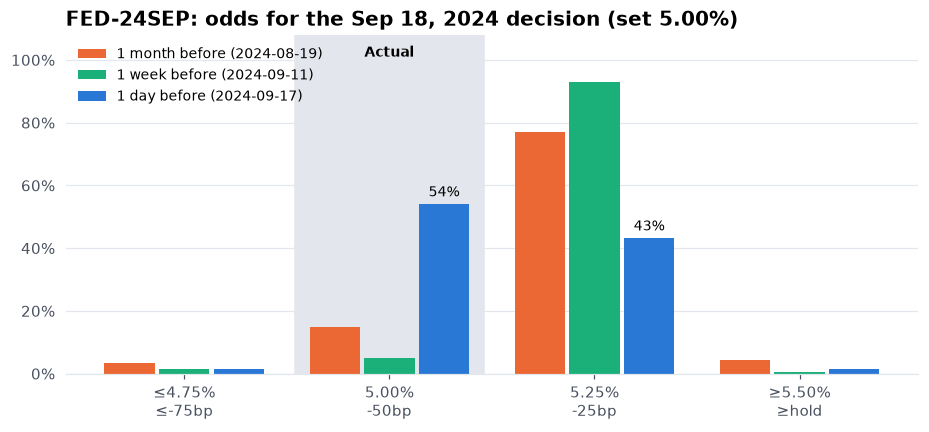

In [10]:
odds_chart("FED-22JUN")
odds_chart("FED-24SEP")

## 6. Expectations versus the actual target, 2021 to today

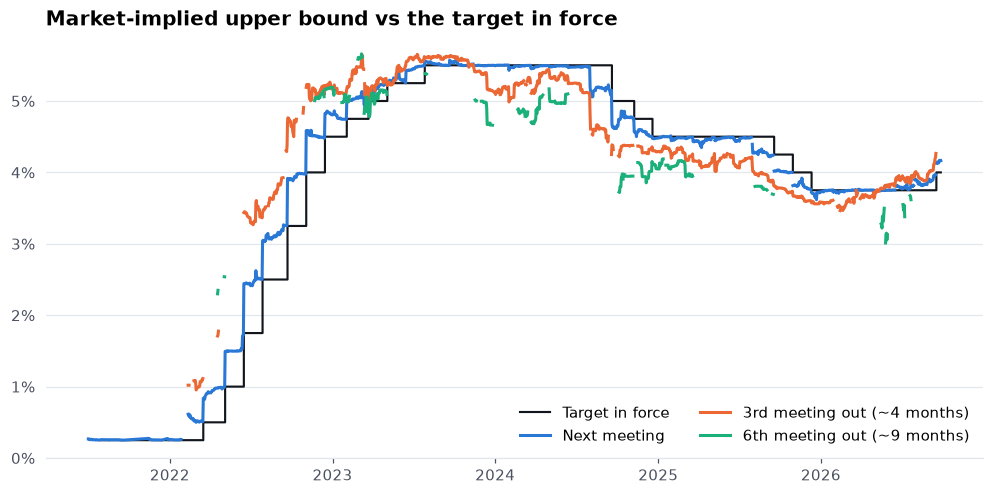

In [11]:
fig, ax = plt.subplots(figsize=(11, 5))
ax.step(horizon.date, horizon.current_target, where="post", color=C["ink"], lw=1.4, label="Target in force")
ax.plot(horizon.date, horizon.next_implied, color=C["s1"], label="Next meeting")
ax.plot(horizon.date, horizon.third_implied, color=C["s2"], label="3rd meeting out (~4 months)")
ax.plot(horizon.date, horizon.sixth_implied, color=C["s3"], label="6th meeting out (~9 months)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.set_ylim(bottom=0)
ax.set_title("Market-implied upper bound vs the target in force")
ax.legend(loc="lower right", ncol=2)
plt.show()

## 7. Every implied path at once (hair chart)

The heavy black step is the target in force. Each thin line starts from it on the first trading day of a month and runs through the implied upper bound for every upcoming meeting that's reliably priced that day. It is the path the market expected from that date.

Where the hairs bend away from the black line, the market was wrong about what came next. This is the standard way to show forward-rate forecasts against realized policy.

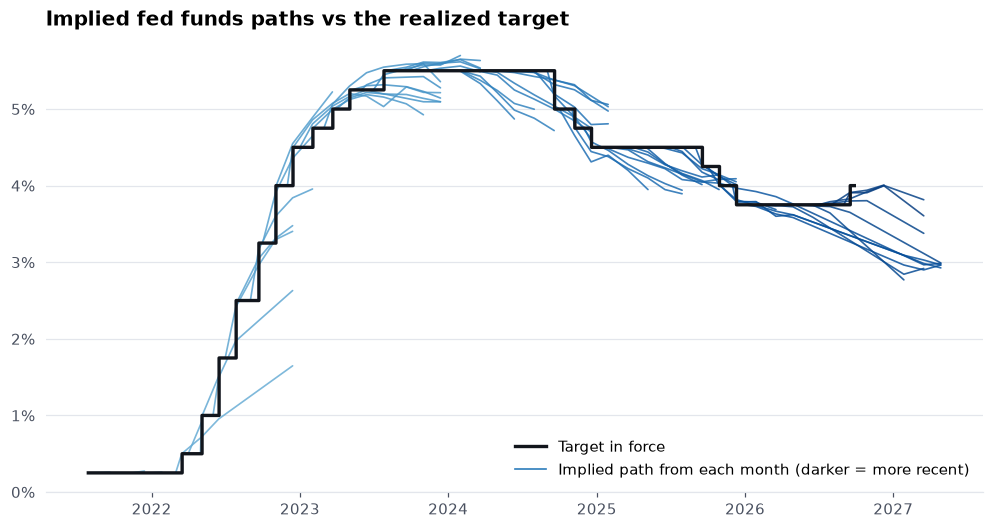

In [12]:
fig, ax = plt.subplots(figsize=(11, 5.4))
cmap = plt.cm.Blues
snaps = horizon.groupby(horizon.date.dt.to_period("M")).date.min()
for k, d in enumerate(snaps):
    ds = d.strftime("%Y-%m-%d")
    snap = rates[(rates.date == ds) & rates.reliable & (rates.meeting_date >= ds)].sort_values("meeting_date")
    tgt = horizon.loc[horizon.date == d, "current_target"].iloc[0]
    if len(snap) == 0 or np.isnan(tgt):
        continue
    xs = [d] + list(pd.to_datetime(snap.meeting_date))
    ys = [tgt] + list(snap.implied_upper_bound)
    ax.plot(xs, ys, color=cmap(0.45 + 0.5 * k / len(snaps)), lw=1.1, alpha=0.85, solid_capstyle="round")
ax.step(horizon.date, horizon.current_target, where="post", color=C["ink"], lw=2.2, label="Target in force", zorder=5)
ax.plot([], [], color=cmap(0.7), lw=1.1, label="Implied path from each month (darker = more recent)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0f}%"))
ax.set_ylim(bottom=0)
ax.set_title("Implied fed funds paths vs the realized target")
ax.legend(loc="lower right")
plt.show()

## 8. Meeting explorer

Set `MEETING` to any event ticker (see the list printed below) and re-run the cell. The top panel is the implied rate over the ladder's life: solid blue where the ladder prices the full distribution, faint gray dashes on unreliable days. The bottom panel is the probability of each 25bp outcome, computed from reliable days only. Outcomes that never reach 10% are folded into the nearest shown bucket.

Meetings: FED-21JUL FED-21SEP FED-21DEC FED-22JAN FED-22MAR FED-22MAY FED-22JUN FED-22JUL FED-22SEP FED-22NOV FED-22DEC FED-23FEB FED-23MAR FED-23MAY FED-23JUN FED-23JUL FED-23SEP FED-23NOV FED-23DEC FED-24JAN FED-24MAR FED-24MAY FED-24JUN FED-24JUL FED-24SEP FED-24NOV FED-24DEC FED-25JAN FED-25MAR FED-25MAY FED-25JUN FED-25JUL FED-25SEP FED-25OCT FED-25DEC KXFED-26JAN KXFED-26MAR KXFED-26APR KXFED-26JUN KXFED-26JUL KXFED-26SEP KXFED-26OCT KXFED-26DEC KXFED-27JAN KXFED-27MAR KXFED-27APR KXFED-27JUN KXFED-27SEP KXFED-27OCT KXFED-27DEC KXFED-28JAN


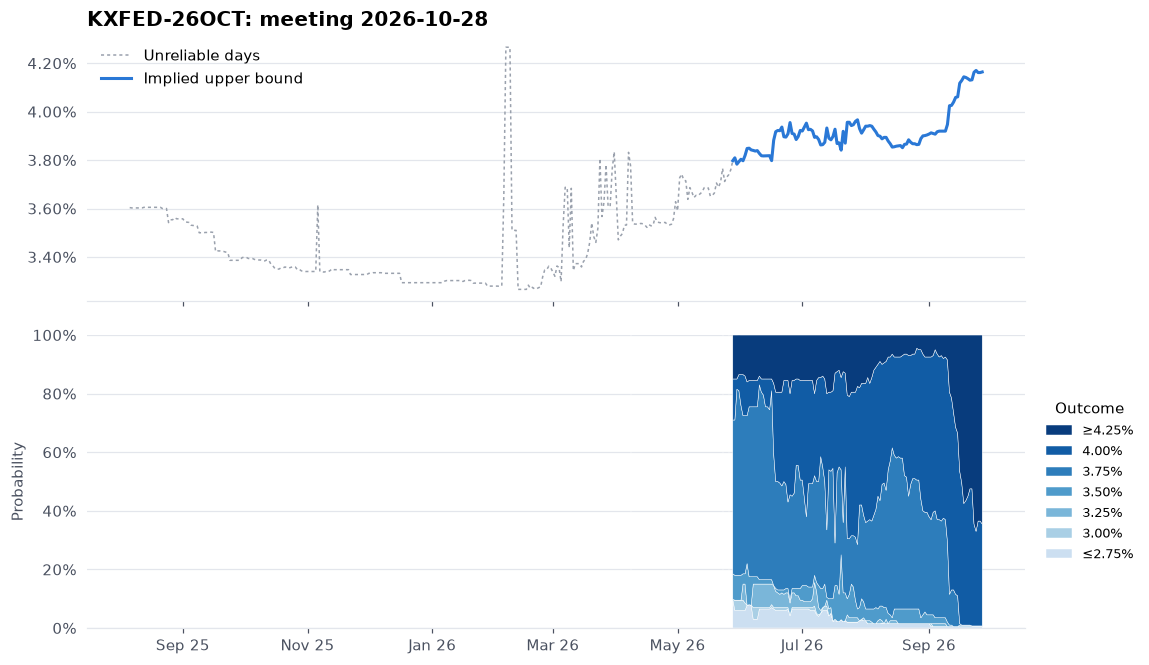

In [13]:
def explore(meeting):
    g = rates[rates.event_ticker == meeting].copy()
    g["dt"] = pd.to_datetime(g.date)
    grid = pd.DataFrame([on_grid(json.loads(x)) for x in g.distribution], index=g.dt).fillna(0)
    grid = grid[sorted(grid.columns)]
    grid[~g.reliable.to_numpy()] = np.nan   # don't draw distributions we can't trust
    keep = [c for c in grid.columns if grid[c].max() >= 0.10] or list(grid.columns)
    lo, hi = grid.columns.get_loc(keep[0]), grid.columns.get_loc(keep[-1])
    shown = grid.iloc[:, lo:hi + 1].copy()
    shown.iloc[:, 0] += grid.iloc[:, :lo].sum(axis=1)
    shown.iloc[:, -1] += grid.iloc[:, hi + 1:].sum(axis=1)
    # The lowest bucket always holds "at or below", the highest "at or above".
    labels = [("≤" if i == 0 else "≥" if i == len(shown.columns) - 1 else "") + f"{c:.2f}%"
              for i, c in enumerate(shown.columns)]

    fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True, gridspec_kw={"height_ratios": [1, 1.1], "hspace": 0.12})
    a1.plot(g.dt, g.implied_upper_bound, color="#9aa1ad", lw=1, ls=(0, (2, 2)), label="Unreliable days")
    a1.plot(g.dt, g.implied_upper_bound.where(g.reliable), color=C["s1"], label="Implied upper bound")
    r = realized[realized.event_ticker == meeting]
    if len(r):
        a1.axhline(r.upper_bound.iloc[0], color=C["ink"], lw=1.2, ls="--", label=f"Realized {r.upper_bound.iloc[0]:.2f}%")
    a1.yaxis.set_major_formatter(pct)
    a1.legend(loc="upper left")
    a1.set_title(f"{meeting}: meeting {g.meeting_date.iloc[0]}")

    colors = plt.cm.Blues(np.linspace(0.22, 0.95, len(labels)))
    a2.stackplot(shown.index, shown.T.to_numpy(), colors=colors, labels=labels, edgecolor="white", linewidth=0.3)
    a2.set_ylim(0, 1); a2.set_ylabel("Probability")
    a2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
    h, l = a2.get_legend_handles_labels()
    a2.legend(h[::-1], l[::-1], loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=8.5, title="Outcome")
    a2.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
    plt.show()


print("Meetings:", " ".join(sorted(rates.event_ticker.unique(), key=lambda e: rates[rates.event_ticker == e].meeting_date.iloc[0])))
MEETING = nxt.event_ticker   # e.g. "FED-22NOV", "FED-24SEP", "KXFED-26DEC"
explore(MEETING)

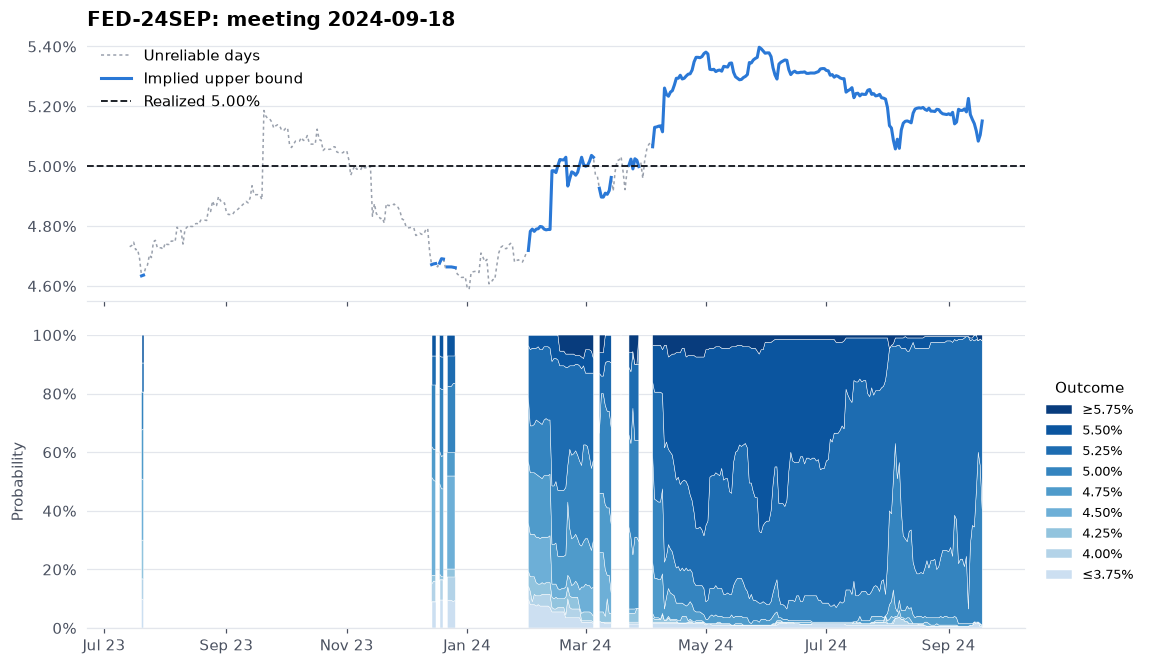

In [14]:
explore("FED-24SEP")   # the 50bp cut in Sep 2024: watch the market swing between 25bp and 50bp

## 9. Scorecard: implied rate the day before each meeting vs the decision

In [15]:
(scorecard.sort_values("meeting_date", ascending=False)
 .style.format({"implied_upper_bound": "{:.3f}%", "realized": "{:.2f}%",
                "change_bp": lambda v: "–" if pd.isna(v) else ("hold" if v == 0 else f"{v:+.0f}bp"),
                "error_bp": "{:+.1f}"})
 .hide(axis="index"))

event_ticker,meeting_date,last_quote_date,implied_upper_bound,realized,change_bp,error_bp
KXFED-26SEP,2026-09-16,2026-09-15,3.969%,4.00%,+25bp,-3.1
KXFED-26JUL,2026-07-29,2026-07-28,3.816%,3.75%,hold,+6.6
KXFED-26JUN,2026-06-17,2026-06-16,3.754%,3.75%,hold,+0.4
KXFED-26APR,2026-04-29,2026-04-28,3.754%,3.75%,hold,+0.4
KXFED-26MAR,2026-03-18,2026-03-17,3.754%,3.75%,hold,+0.4
KXFED-26JAN,2026-01-28,2026-01-27,3.754%,3.75%,hold,+0.4
FED-25DEC,2025-12-10,2025-12-09,3.761%,3.75%,-25bp,+1.1
FED-25OCT,2025-10-29,2025-10-28,4.001%,4.00%,-25bp,+0.1
FED-25SEP,2025-09-17,2025-09-16,4.241%,4.25%,-25bp,-0.9
FED-25JUL,2025-07-30,2025-07-29,4.491%,4.50%,hold,-0.9


## 10. Forecast errors by horizon

For every reliable day, the implied upper bound minus the rate the Fed eventually set at that meeting, in basis points. Negative means the market expected a lower rate than it got. Bars are the share of days in each 10bp bin; days beyond ±120bp are folded into the end bins.

Consecutive days forecasting the same meeting overlap heavily, so the day counts overstate how many independent forecasts there are. There are 41 settled meetings behind these.

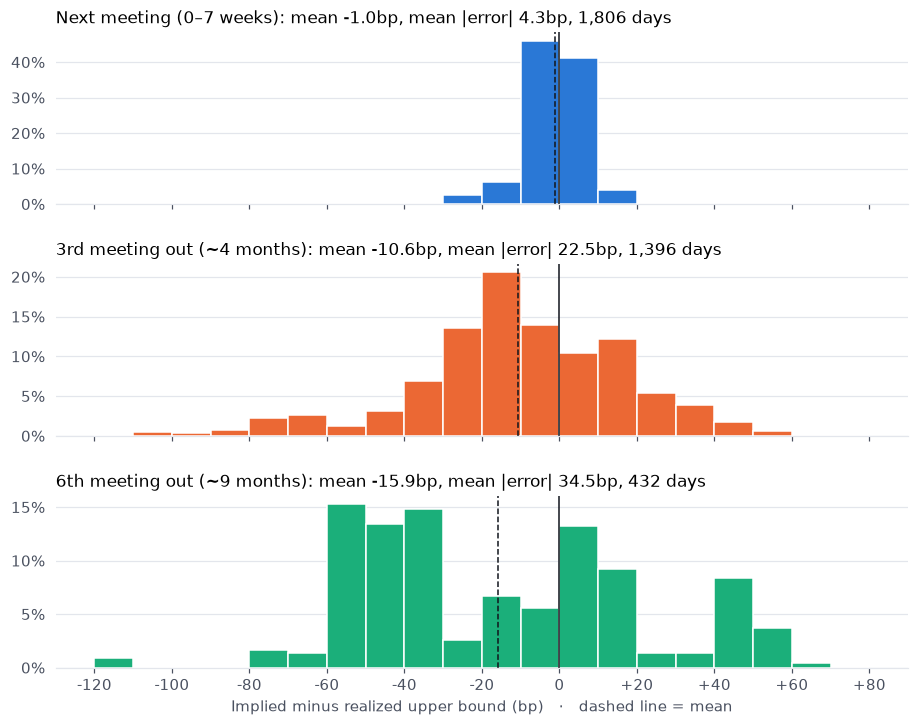

In [16]:
rm = dict(zip(realized.meeting_date, realized.upper_bound))
bins = np.arange(-120, 81, 10)
fig, axes = plt.subplots(3, 1, figsize=(10, 7.5), sharex=True, gridspec_kw={"hspace": 0.35})
for ax, (col, label, color) in zip(axes, [("next", "Next meeting (0–7 weeks)", C["s1"]),
                                           ("third", "3rd meeting out (~4 months)", C["s2"]),
                                           ("sixth", "6th meeting out (~9 months)", C["s3"])]):
    d = horizon.dropna(subset=[f"{col}_implied"])
    real = d[f"{col}_meeting"].map(rm)
    e = ((d[f"{col}_implied"] - real) * 100).dropna()
    ax.hist(e.clip(bins[0], bins[-1] - 0.01), bins=bins, weights=np.full(len(e), 1 / len(e)),
            color=color, edgecolor="white", linewidth=1)
    ax.axvline(0, color=C["ink"], lw=1)
    ax.axvline(e.mean(), color=C["ink"], lw=1, ls="--")
    ax.set_title(f"{label}: mean {e.mean():+.1f}bp, mean |error| {e.abs().mean():.1f}bp, {len(e):,} days",
                 fontsize=11, fontweight="normal")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
axes[-1].set_xlabel("Implied minus realized upper bound (bp)   ·   dashed line = mean")
axes[-1].set_xticks(bins[::2], [f"{b:+d}" if b else "0" for b in bins[::2]])
plt.show()

## 11. Track record: probability on the actual decision

For each settled meeting, the probability the market put on the decision the Fed actually made, 1 day, 1 week and 1 month before. This measures accuracy without averaging: a market that is right with 97% confidence and one that is right with 55% both have a small error in the mean, but very different odds.

,median,share ≥ 90%,meetings < 50%,meetings
1 day before,97%,85%,0.000000,41.000000
1 week before,95%,68%,2.000000,41.000000
1 month before,81%,27%,5.000000,39.000000


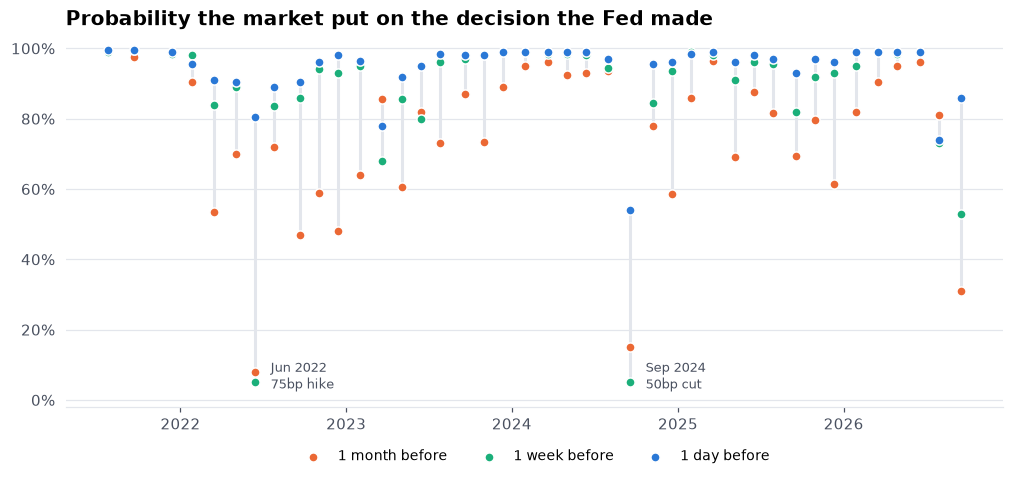

In [17]:
rows = []
for _, mt in realized.iterrows():
    rec = {"event_ticker": mt.event_ticker, "meeting_date": mt.meeting_date, "realized": mt.upper_bound}
    for lag, name in ((1, "1d"), (7, "1w"), (30, "1m")):
        cut = (pd.Timestamp(mt.meeting_date) - pd.Timedelta(days=lag)).strftime("%Y-%m-%d")
        g = rates[(rates.event_ticker == mt.event_ticker) & (rates.date <= cut)]
        if len(g):
            gd = on_grid(json.loads(g.distribution.iloc[-1]))
            k0 = min(gd)
            rec[f"p_{name}"] = gd.get(mt.upper_bound, 0) if mt.upper_bound > k0 else sum(v for k, v in gd.items() if k <= k0)
            rec[f"date_{name}"], rec[f"reliable_{name}"] = g.date.iloc[-1], bool(g.reliable.iloc[-1])
    rows.append(rec)
track = pd.DataFrame(rows)
track.to_csv(DATA / "track_record.csv", index=False)

summary = pd.DataFrame({lab: {"median": track[c].median(), "share ≥ 90%": (track[c] >= 0.9).mean(),
                              "meetings < 50%": int((track[c] < 0.5).sum()), "meetings": int(track[c].notna().sum())}
                        for lab, c in [("1 day before", "p_1d"), ("1 week before", "p_1w"), ("1 month before", "p_1m")]}).T
display(summary.style.format({"median": "{:.0%}", "share ≥ 90%": "{:.0%}"}))

fig, ax = plt.subplots(figsize=(11, 4.4))
xs = pd.to_datetime(track.meeting_date)
for _, r in track.iterrows():
    ys = [r[c] for c in ("p_1m", "p_1w", "p_1d") if pd.notna(r[c])]
    ax.vlines(pd.Timestamp(r.meeting_date), min(ys), max(ys), color=C["grid"], lw=2, zorder=1)
for c, lab, col in [("p_1m", "1 month before", C["s2"]), ("p_1w", "1 week before", C["s3"]), ("p_1d", "1 day before", C["s1"])]:
    ax.scatter(xs, track[c], s=36, color=col, edgecolor="white", linewidth=1, zorder=2, label=lab)
for ev, txt in [("FED-22JUN", "Jun 2022\n75bp hike"), ("FED-24SEP", "Sep 2024\n50bp cut")]:
    r = track[track.event_ticker == ev].iloc[0]
    ax.annotate(txt, (pd.Timestamp(r.meeting_date), r.p_1w), xytext=(10, -4), textcoords="offset points", fontsize=8.5, color=C["ink2"])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_ylim(-0.02, 1.04)
ax.set_title("Probability the market put on the decision the Fed made")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), fontsize=9, ncol=3)
plt.show()

## 12. Trade-level data

Every individual trade on every contract, from Kalshi's public trades endpoints. Trades before Kalshi's historical cutoff are only on `/historical/trades`, even for contracts still trading, so both endpoints are queried for every contract. The first run takes several minutes; the result is cached in `data/trades.csv.gz`.

In [18]:
TRADES = DATA / "trades.csv.gz"


def trades_for(ticker):
    rows = []
    for path in ("/historical/trades", "/markets/trades"):
        cursor = None
        while True:
            d = get(path, {"ticker": ticker, "limit": 1000, **({"cursor": cursor} if cursor else {})}) or {}
            rows += d.get("trades", [])
            cursor = d.get("cursor")
            if not cursor:
                break
    return rows


if REFRESH or not TRADES.exists():
    raw = []
    for i, t in enumerate(markets.ticker):
        raw += trades_for(t)
        if i % 100 == 0:
            print(f"  {i}/{len(markets)} contracts, {len(raw):,} trades")
    trades = (pd.DataFrame(raw).drop_duplicates("trade_id")
              .assign(yes_price=lambda d: d.yes_price_dollars.astype(float), count=lambda d: d.count_fp.astype(float))
              [["ticker", "created_time", "yes_price", "count", "taker_side", "is_block_trade", "trade_id"]]
              .sort_values(["ticker", "created_time"]))
    trades.to_csv(TRADES, index=False, compression="gzip")
trades = pd.read_csv(TRADES)
trades["created_time"] = pd.to_datetime(trades.created_time, utc=True, format="ISO8601")

# Completeness check: for settled contracts, traded volume should equal Kalshi's reported volume.
vol = trades.groupby("ticker")["count"].sum()
chk = markets[markets.status == "finalized"].set_index("ticker").volume
match = ((vol.reindex(chk.index).fillna(0) - chk).abs() <= 0.01 * chk.clip(lower=1))
print(f"{len(trades):,} trades on {trades.ticker.nunique()} contracts, "
      f"{trades.created_time.min():%Y-%m-%d} to {trades.created_time.max():%Y-%m-%d}")
print(f"Settled contracts whose trades sum to the reported volume (±1%): {match.mean():.0%} of {len(chk)}")

221,859 trades on 587 contracts, 2021-07-02 to 2026-09-28
Settled contracts whose trades sum to the reported volume (±1%): 100% of 413


## 13. Replication: Diercks, Katz & Wright (2026)

Diercks, Katz and Wright, *Kalshi and the Rise of Macro Markets* (NBER WP 34702 / FEDS 2026-010), build the same ladder distributions with three differences from our method:

| Step | Diercks–Katz–Wright | Ours (sections 2–4) |
|---|---|---|
| Contract price | Last trade, carried forward on days without a trade | Bid/ask midpoint if spread ≤ 20¢; last trade clipped to the quote if ≤ 40¢; otherwise dropped |
| Monotonicity | Built outward from the mode toward the tails | Weighted isotonic fit (tighter quotes weigh more) |
| Filtering | None | Reliability flag |

This section rebuilds the distributions their way from the trade-level data: the last trade of each ET calendar day, carried forward, then made monotone outward from the mode. Everything downstream (differencing, bucket values, mean, mode, median) is shared with our method so the comparison isolates the two choices. Both methods are scored against the realized decision, on the full sample and on their window (meetings in 2022–2025).

Two limitations. Their paper doesn't state a time of day for the last trade, so end of ET day is our assumption. Their rule for ties ("assign the probability to the outcome closer to the mode") only matters when two strikes trade at the same price; with mode-outward monotonicity that gives a zero bucket, which is what we do.

In [19]:
def mode_outward(P):
    # DKW monotonicity: anchor the strikes either side of the mode bucket, then
    # force P(>k) to fall moving right and rise moving left.
    Q = np.clip(np.asarray(P, float), 0, 1)
    b = np.r_[1 - Q[0], Q[:-1] - Q[1:], Q[-1]]   # bucket j sits between strike j-1 and strike j
    j = int(np.argmax(b))
    for i in range(j + 1, len(Q)):
        Q[i] = min(Q[i], Q[i - 1])
    for i in range(j - 2, -1, -1):
        Q[i] = max(Q[i], Q[i + 1])
    return Q


def ladder_stats(k, p):
    # Same bucket construction and valuation as implied() in section 2.
    probs = {f"p_le_{k[0]:.2f}": 1 - p[0]}
    mean, wide = k[0] * (1 - p[0]), 0.0
    for i in range(len(k)):
        hi = p[i + 1] if i + 1 < len(k) else 0.0
        top = k[i + 1] if i + 1 < len(k) else k[i] + STEP
        probs[f"p_{top:.2f}"] = p[i] - hi
        mean += (k[i] + STEP + top) / 2 * (p[i] - hi)
        wide += (p[i] - hi) if top - k[i] > 2 * STEP else 0
    lo_tail, hi_tail = (0.0 if k[0] <= 0.25 else 1 - p[0]), p[-1]
    return probs, mean, bool(lo_tail <= 0.10 and hi_tail <= 0.10 and wide <= 0.10)


def point_forecasts(dist):
    g = on_grid(dist)
    ks = sorted(g)
    cdf = np.cumsum([g[k] for k in ks])
    return max(g, key=g.get), ks[int(np.searchsorted(cdf, 0.5))]   # mode, median


# Daily last trade per contract (ET calendar day), carried forward to the meeting.
tr = trades.sort_values("created_time").assign(date=lambda d: d.created_time.dt.tz_convert("America/New_York").dt.strftime("%Y-%m-%d"))
daily_last = tr.groupby(["ticker", "date"]).yes_price.last().to_frame("price")
daily_last["last_trade"] = daily_last.index.get_level_values("date")
mk = markets.set_index("ticker")
grid = []
for t, g in daily_last.groupby(level="ticker"):
    g = g.droplevel("ticker")
    end = min(mk.meeting_date[t], asof)
    if g.index.min() > end:
        continue
    days = pd.date_range(g.index.min(), end).strftime("%Y-%m-%d")
    g = g.reindex(days).ffill()
    grid.append(g.assign(ticker=t, event_ticker=mk.event_ticker[t], strike=mk.strike[t],
                         meeting_date=mk.meeting_date[t]).rename_axis("date").reset_index())
grid = pd.concat(grid)
grid["trade_age"] = (pd.to_datetime(grid.date) - pd.to_datetime(grid.last_trade)).dt.days

rows = []
for (ev, d), g in grid.groupby(["event_ticker", "date"]):
    g = g.sort_values("strike")
    k = g.strike.to_numpy()
    probs, mean, rel = ladder_stats(k, mode_outward(g.price.to_numpy()))
    mode, med = point_forecasts(probs)
    rows.append({"event_ticker": ev, "meeting_date": g.meeting_date.iloc[0], "date": d, "implied_upper_bound": round(mean, 4),
                 "mode": mode, "median": med, "reliable": rel, "n_strikes": len(k),
                 "median_trade_age_days": g.trade_age.median(), "distribution": json.dumps({a: round(b, 4) for a, b in probs.items()})})
dkw = pd.DataFrame(rows).sort_values(["meeting_date", "date"])
dkw.to_csv(DATA / "implied_rate_daily_dkw.csv", index=False)

ours = rates.copy()
ours[["mode", "median"]] = [point_forecasts(json.loads(x)) for x in ours.distribution]
print(f"DKW method: {len(dkw):,} meeting-days ({dkw.reliable.mean():.0%} would pass our reliability flag); "
      f"ours: {len(ours):,}")

DKW method: 12,769 meeting-days (52% would pass our reliability flag); ours: 12,916


In [20]:
def scored(df):
    x = df.merge(realized[["event_ticker", "upper_bound"]], on="event_ticker")
    x["h"] = (pd.to_datetime(x.meeting_date) - pd.to_datetime(x.date)).dt.days
    x = x[(x.h >= 1) & (x.h <= 160)].copy()
    x["err_mean"] = (x.implied_upper_bound - x.upper_bound).abs() * 100
    x["err_mode"] = (x["mode"] - x.upper_bound).abs() * 100
    x["err_median"] = (x["median"] - x.upper_bound).abs() * 100
    return x


def prob_on_actual(df, lag):
    out = []
    for _, mt in realized.iterrows():
        cut = (pd.Timestamp(mt.meeting_date) - pd.Timedelta(days=lag)).strftime("%Y-%m-%d")
        g = df[(df.event_ticker == mt.event_ticker) & (df.date <= cut)]
        if len(g):
            gd = on_grid(json.loads(g.distribution.iloc[-1]))
            k0 = min(gd)
            out.append(gd.get(mt.upper_bound, 0) if mt.upper_bound > k0 else sum(v for k, v in gd.items() if k <= k0))
    return np.median(out) if out else np.nan


S_ours, S_dkw = scored(ours), scored(dkw)
key = ["event_ticker", "date"]
both = S_ours[key].merge(S_dkw[key], on=key)   # matched sample: same meeting-days for both methods


def summarize(S, name, df_full, subset=None):
    S = S.merge(both, on=key)
    if subset is not None:
        S = S[subset(S)]
    at = lambda h: S[S.h == h]
    noise = (S.sort_values(key).groupby("event_ticker").implied_upper_bound.diff().abs() * 100).mean()
    return {"method": name, "meeting-days": len(S), "meetings": S.event_ticker.nunique(),
            "mode right, 1 day before": (at(1).err_mode == 0).mean(),
            "MAE mean, 1 day (bp)": at(1).err_mean.mean(), "MAE mean, 1 week": at(7).err_mean.mean(),
            "MAE mean, 1 month": at(30).err_mean.mean(), "MAE mean, 3 months": at(90).err_mean.mean(),
            "MAE mean, 1–160 days": S.err_mean.mean(), "MAE mode, 1–160 days": S.err_mode.mean(),
            "avg daily change (bp)": noise,
            "P(actual), 1 day": prob_on_actual(df_full, 1), "P(actual), 1 month": prob_on_actual(df_full, 30)}


window = lambda S: S.meeting_date.between("2022-01-01", "2025-12-31")
reliable_days = S_ours.loc[S_ours.reliable, key]
comparison = pd.DataFrame([
    summarize(S_dkw, "DKW (last trade, mode-outward)", dkw),
    summarize(S_ours, "Ours (quotes, isotonic)", ours),
    summarize(S_dkw, "DKW · their window 2022–25", dkw, window),
    summarize(S_ours, "Ours · their window 2022–25", ours, window),
    summarize(S_dkw.merge(reliable_days, on=key), "DKW · our reliable days only", dkw),
    summarize(S_ours.merge(reliable_days, on=key), "Ours · reliable days only", ours),
]).set_index("method")
comparison.to_csv(DATA / "method_comparison.csv")
display(comparison.style.format("{:.1f}").format("{:.0%}", subset=["mode right, 1 day before", "P(actual), 1 day", "P(actual), 1 month"])
        .format("{:,.0f}", subset=["meeting-days", "meetings"]))
age = dkw.merge(S_dkw[key + ["h"]], on=key)
print("Median age of the last trade behind each DKW price (days): "
      f"1 day before {age[age.h == 1].median_trade_age_days.median():.0f}, "
      f"1 month before {age[age.h == 30].median_trade_age_days.median():.0f}, "
      f"3 months before {age[age.h == 90].median_trade_age_days.median():.0f}")

,meeting-days,meetings,"mode right, 1 day before","MAE mean, 1 day (bp)","MAE mean, 1 week","MAE mean, 1 month","MAE mean, 3 months","MAE mean, 1–160 days","MAE mode, 1–160 days",avg daily change (bp),"P(actual), 1 day","P(actual), 1 month"
method,,,,,,,,,,,,
"DKW (last trade, mode-outward)","5,934",41,100%,1.6,3.0,5.9,21.9,20.8,21.0,1.6,97%,80%
"Ours (quotes, isotonic)","5,934",41,100%,1.2,2.7,5.9,19.3,17.9,16.1,1.3,97%,81%
DKW · their window 2022–25,"4,870",32,100%,1.6,3.2,6.2,25.0,22.7,22.4,1.5,97%,80%
Ours · their window 2022–25,"4,870",32,100%,1.2,2.9,6.3,21.7,19.9,18.0,1.4,97%,81%
DKW · our reliable days only,"5,349",41,100%,1.6,3.0,5.9,19.7,17.0,17.1,1.6,97%,80%
Ours · reliable days only,"5,349",41,100%,1.2,2.7,5.9,16.8,14.0,11.8,1.2,97%,81%


Median age of the last trade behind each DKW price (days): 1 day before 6, 1 month before 3, 3 months before 4


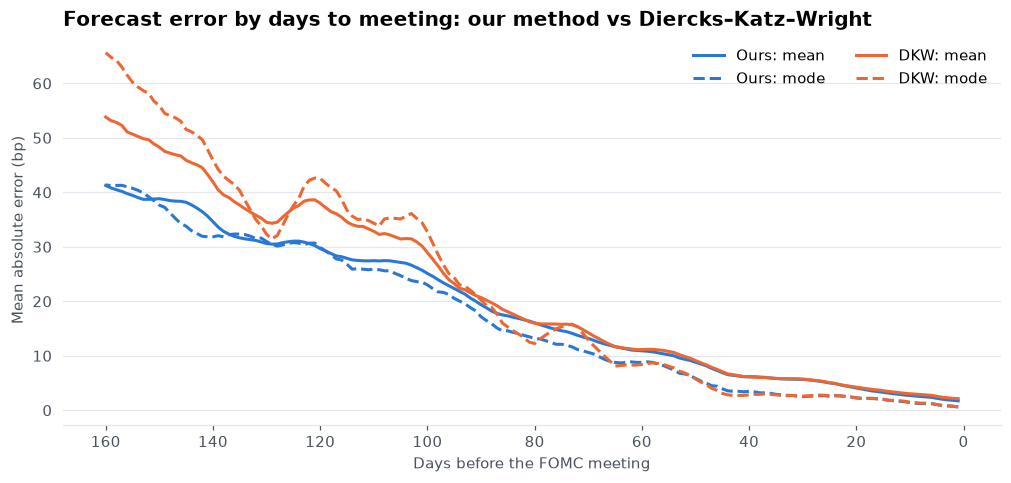

In [21]:
# Their Figure 1 layout: mean absolute error against days before the meeting (matched sample, 7-day smoothing).
fig, ax = plt.subplots(figsize=(11, 4.6))
for S, lab, col, ls in [(S_ours, "Ours: mean", C["s1"], "-"), (S_ours, "Ours: mode", C["s1"], "--"),
                        (S_dkw, "DKW: mean", C["s2"], "-"), (S_dkw, "DKW: mode", C["s2"], "--")]:
    col_err = "err_mean" if "mean" in lab else "err_mode"
    curve = S.merge(both, on=key).groupby("h")[col_err].mean().rolling(7, center=True, min_periods=1).mean()
    ax.plot(curve.index, curve.values, color=col, ls=ls, label=lab)
ax.invert_xaxis()
ax.set_xlabel("Days before the FOMC meeting")
ax.set_ylabel("Mean absolute error (bp)")
ax.set_title("Forecast error by days to meeting: our method vs Diercks–Katz–Wright")
ax.legend(loc="upper right", ncol=2)
plt.show()

### Which change matters? A 2×2 ablation

Our method differs from theirs in two independent choices: how each contract is priced (last trade vs quotes) and how the ladder is made monotone (outward from the mode vs isotonic fit). Running all four combinations on the same meeting-days attributes the difference to each choice. The quotes + isotonic cell must reproduce our main series exactly, which is checked first.

In [22]:
def quote_prices():
    # The pricing step of implied() in section 2, kept separate so it can be paired with either monotonicity rule.
    df = daily_grid(candles, markets).merge(markets[["ticker", "meeting_date"]], on="ticker")
    df = df[df.date <= df.meeting_date]
    spread = df.yes_ask - df.yes_bid
    last = df["last"].clip(lower=df.yes_bid, upper=df.yes_ask)
    df["price"] = ((df.yes_bid + df.yes_ask) / 2).where(spread.between(0, 0.20), last.where(spread.between(0, 0.40)))
    df["w"] = 1 / (spread.clip(lower=0).fillna(1) + 0.02)
    return df.dropna(subset=["price"])[["event_ticker", "meeting_date", "date", "strike", "price", "w"]]


def build(prices, monotone):
    rows = []
    for (ev, d), g in prices.groupby(["event_ticker", "date"]):
        g = g.sort_values("strike")
        k, P = g.strike.to_numpy(), g.price.to_numpy()
        p = np.clip(pava_decreasing(P, g.w.to_numpy()), 0, 1) if monotone == "isotonic" else mode_outward(P)
        probs, mean, rel = ladder_stats(k, p)
        mode, med = point_forecasts({a: round(b, 4) for a, b in probs.items()})
        rows.append({"event_ticker": ev, "meeting_date": g.meeting_date.iloc[0], "date": d, "implied_upper_bound": round(mean, 4),
                     "mode": mode, "median": med, "reliable": rel})
    return pd.DataFrame(rows)


trade_prices = grid[["event_ticker", "meeting_date", "date", "strike", "price"]].assign(w=1.0)
qp = quote_prices()
variants = {
    ("Last trade", "Mode-outward"): build(trade_prices, "mode_outward"),
    ("Last trade", "Isotonic"): build(trade_prices, "isotonic"),
    ("Quotes", "Mode-outward"): build(qp, "mode_outward"),
    ("Quotes", "Isotonic"): build(qp, "isotonic"),
}
check = variants[("Quotes", "Isotonic")].merge(rates[key + ["implied_upper_bound"]], on=key, suffixes=("", "_main"))
print(f"Quotes + isotonic reproduces the main series: max difference "
      f"{(check.implied_upper_bound - check.implied_upper_bound_main).abs().max():.6f} over {len(check):,} meeting-days")

scored_v = {kk: scored(v) for kk, v in variants.items()}
common = None
for S in scored_v.values():
    common = S[key] if common is None else common.merge(S[key], on=key)
abl = []
for (price, mono), S in scored_v.items():
    S = S.merge(common, on=key)
    abl.append({"price": price, "monotonicity": mono,
                "MAE mean, 1 day": S[S.h == 1].err_mean.mean(), "MAE mean, 1 month": S[S.h == 30].err_mean.mean(),
                "MAE mean, 3 months": S[S.h == 90].err_mean.mean(), "MAE mean, 1–160 days": S.err_mean.mean(),
                "MAE mode, 1–160 days": S.err_mode.mean(),
                "avg daily change": (S.sort_values(key).groupby("event_ticker").implied_upper_bound.diff().abs() * 100).mean()})
ablation = pd.DataFrame(abl)
ablation.to_csv(DATA / "ablation.csv", index=False)
print(f"Matched sample: {len(common):,} meeting-days")
display(ablation.style.format("{:.1f}", subset=ablation.columns[2:]).hide(axis="index"))

# How old are the trades behind last-trade prices?
ag = grid.merge(S_dkw[key + ["h"]].drop_duplicates(), on=key)
stale = {h: float((ag[ag.h == h].trade_age > 7).mean()) for h in (1, 7, 30, 90)}
print("Share of contract prices whose last trade is more than a week old:",
      ", ".join(f"{h} days before {v:.0%}" for h, v in stale.items()))

Quotes + isotonic reproduces the main series: max difference 0.000000 over 12,916 meeting-days
Matched sample: 5,934 meeting-days


price,monotonicity,"MAE mean, 1 day","MAE mean, 1 month","MAE mean, 3 months","MAE mean, 1–160 days","MAE mode, 1–160 days",avg daily change
Last trade,Mode-outward,1.6,5.9,21.9,20.8,21.0,1.6
Last trade,Isotonic,2.8,6.7,20.8,20.2,17.9,1.2
Quotes,Mode-outward,1.2,5.8,19.3,18.0,16.3,1.4
Quotes,Isotonic,1.2,5.9,19.3,17.9,16.1,1.3


Share of contract prices whose last trade is more than a week old: 1 days before 42%, 7 days before 45%, 30 days before 40%, 90 days before 43%


## 14. Benchmark: NY Fed Survey of Market Expectations

Before each FOMC meeting the New York Fed asks primary dealers for their most likely target rate after each upcoming meeting. We use the **median of dealers' modal forecasts**, which is what the survey publishes, and compare it with Kalshi on the survey's due date. The survey reports the midpoint of the range, so the upper bound is midpoint + 0.125.

Coverage: the spreadsheets published since July 2023, and the text results PDFs before that (March 2021 to September 2022). The results for November 2022 to June 2023 are image-only PDFs and can't be read, and three 2021 PDFs use a layout the parser doesn't handle; those surveys are skipped. The dealer panel is used throughout because it's the only one surveyed for the whole period. The survey is a *modal* forecast, so the like-for-like Kalshi comparison is its mode; the mean is shown too.

In [23]:
# Parsing the older PDFs needs pypdf (pip install pypdf); without it only the spreadsheets are used.
import re
from datetime import date
try:
    from pypdf import PdfReader
except ImportError:
    PdfReader = None
    print("pypdf not installed: using spreadsheets only (July 2023 onward)")

NY = "https://www.newyorkfed.org"
MONTH = {m: i + 1 for i, m in enumerate(["jan", "feb", "mar", "apr", "may", "jun", "jul", "aug", "sep", "oct", "nov", "dec"])}
MONS = "Jan|Feb|Mar|Apr|May|Jun|Jul|Aug|Sep|Oct|Nov|Dec"
HDR_RE = re.compile(rf"({MONS})[a-z]*\.?\s*(\d{{1,2}})(?!\d)\s*(?:-\s*(?:({MONS})[a-z]*\.?\s*)?(\d{{1,2}})(?!\d))?")


def ny_fetch(url):
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0 (research script)"})
    with urllib.request.urlopen(req, timeout=60, context=SSL_CTX) as r:
        time.sleep(0.3)
        return r.read()


def parse_sme_xlsx(raw):
    df = pd.read_excel(io.BytesIO(raw))
    q = df[(df.question_tag == "fftr_pathofmodes") & df.panel_type.isin(["Dealer", "SPD"]) & (df.aggregation == "pctl50")
           & df.value_tag.str.match(r"fftr_pathofmodes_\d{8}$")]
    due = pd.Timestamp(df.survey_due_date.iloc[0]).date()
    return [(due, pd.Timestamp(r.horizon_date).date(), float(r.aggregation_value) * 100) for r in q.itertuples()]


def parse_sme_pdf(raw, year):
    text = "\n".join(p.extract_text() or "" for p in PdfReader(io.BytesIO(raw)).pages)
    dues = [date(int(y), int(mo), int(d)) for mo, d, y in re.findall(r"Received by:?\s*(\d{1,2})/(\d{1,2})/(\d{4})", text) if int(y) >= year - 1]
    i = text.find("most likely outcome (i.e., the mode) for the target federal funds rate")
    if i < 0:
        return []
    # First percentile table after the question whose column headers are meeting dates ("20-21").
    for m in re.finditer(r"25th Pctl", text[i:]):
        pos = i + m.start()
        prev = max(text.rfind("Pctl", i, pos - 1), text.rfind("Responses", i, pos), text.rfind("response.", i, pos))
        header = text[prev:pos] if prev > 0 else text[i:pos]
        hdrs = HDR_RE.findall(header)
        if len(hdrs) < 3 or re.search(r"Q[1-4]|Year-End", header) or not re.search(r"\d{1,2}\s*-\s*(?:[A-Z][a-z]+\.?\s*)?\d{1,2}", header):
            continue
        med = re.search(r"Median\s+((?:-?\d+\.\d+%\s*)+)", text[pos:pos + 600])
        if not med:
            return []
        vals = [float(v) for v in re.findall(r"(-?\d+\.\d+)%", med.group(1))]
        anchor = max(dues) if dues else date(year, 1, 1)
        mtgs = []
        for mo1, d1, mo2, d2 in hdrs:
            mo, d = (mo2 or mo1), int(d2 or d1)
            mtgs.append(min(c for c in (date(y, MONTH[mo.lower()], d) for y in (anchor.year, anchor.year + 1)) if c >= anchor - timedelta(days=10)))
        due = max(dues) if dues else mtgs[0] - timedelta(days=9)
        return [(due, md, v) for md, v in zip(mtgs, vals)]
    return []


SME = DATA / "nyfed_sme.csv"
if REFRESH or not SME.exists():
    html = ny_fetch(f"{NY}/markets/primarydealer_survey_questions").decode("utf-8", "ignore")
    links = sorted(set(re.findall(r'href="(/medialibrary/media/markets/survey/(20\d\d)/[^"]+)"', html)))
    rows, skipped = [], []
    for path, yr in links:
        name = path.rsplit("/", 1)[-1].lower()
        if int(yr) < 2021 or not (name.endswith("-data.xlsx") or name.endswith("-spd-results.pdf")):
            continue
        if name.endswith(".pdf") and PdfReader is None:
            continue
        raw = ny_fetch(NY + path)
        rs = parse_sme_xlsx(raw) if name.endswith(".xlsx") else parse_sme_pdf(raw, int(yr))
        rows += [{"survey_due": a, "meeting_date": b, "median_mode_mid": c, "source": name} for a, b, c in rs]
        if not rs:
            skipped.append(name)
    sme = pd.DataFrame(rows)
    sme["xlsx"] = sme.source.str.endswith("xlsx")
    sme = sme.sort_values("xlsx", ascending=False).drop_duplicates(["survey_due", "meeting_date"]).drop(columns="xlsx")
    sme.sort_values(["survey_due", "meeting_date"]).to_csv(SME, index=False)
    print("Files with no readable table (image-only PDFs, or a PDF duplicated by a spreadsheet):", ", ".join(skipped))
sme = pd.read_csv(SME)
print(f"{sme.survey_due.nunique()} dealer surveys, {sme.survey_due.min()} to {sme.survey_due.max()}, {len(sme)} survey-meeting forecasts")

36 dealer surveys, 2021-03-08 to 2026-07-20, 247 survey-meeting forecasts


Matched sample: 132 forecasts from 33 surveys, 37 meetings


,NY Fed survey (median of modes),Kalshi mode (ours),Kalshi mean (ours),Kalshi mode (DKW),Kalshi mean (DKW),forecasts
h,,,,,,
≤ 45 days,1.5,1.5,2.5,1.5,2.9,33
46–90 days,8.3,6.7,10.6,6.7,11.0,30
91–180 days,23.3,21.5,26.8,31.4,29.8,43
> 180 days,47.1,41.3,49.6,63.5,58.0,26
All horizons,19.1,17.0,21.5,24.6,24.4,132


Exactly right: NY Fed survey (median of modes) 57%, Kalshi mode (ours) 59%, Kalshi mode (DKW) 55%


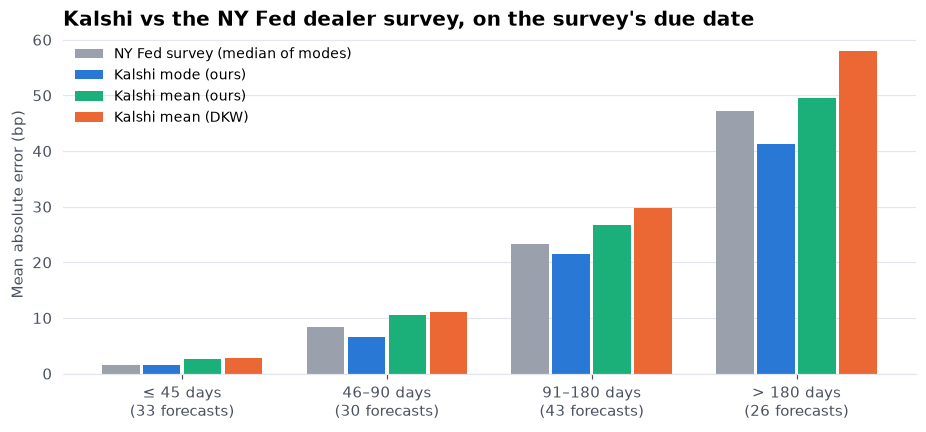

In [24]:
# Match each survey forecast to a Kalshi meeting (dates within 3 days) and to Kalshi's view on the due date.
kalshi_meetings = (realized[["event_ticker", "meeting_date", "upper_bound"]].rename(columns={"meeting_date": "k_meeting_date"})
                   .assign(md=lambda d: pd.to_datetime(d.k_meeting_date)))
sv = sme.assign(md=pd.to_datetime(sme.meeting_date), due=pd.to_datetime(sme.survey_due))
sv = pd.merge_asof(sv.sort_values("md"), kalshi_meetings.sort_values("md"), on="md", direction="nearest",
                   tolerance=pd.Timedelta(days=3)).dropna(subset=["event_ticker"])
sv["survey_ub"] = ((sv.median_mode_mid + 0.125) * 4).round() / 4
sv["h"] = (sv.md - sv.due).dt.days


def kalshi_on(df, ev, day):
    g = df[(df.event_ticker == ev) & (df.date <= day)]
    return g.iloc[-1] if len(g) else None


recs = []
for r in sv.itertuples():
    day = r.due.strftime("%Y-%m-%d")
    o, d = kalshi_on(ours, r.event_ticker, day), kalshi_on(dkw, r.event_ticker, day)
    if o is None or d is None or o.date != day or not o.reliable:
        continue   # matched sample: our ladder reliably priced on the due date, and a DKW price exists
    recs.append({"survey_due": day, "event_ticker": r.event_ticker, "meeting_date": r.k_meeting_date,
                 "h": r.h, "realized": r.upper_bound, "survey": r.survey_ub,
                 "ours_mean": o.implied_upper_bound, "ours_mode": o["mode"], "dkw_mean": d.implied_upper_bound, "dkw_mode": d["mode"]})
sc = pd.DataFrame(recs)
sc.to_csv(DATA / "survey_comparison.csv", index=False)

cols = {"survey": "NY Fed survey (median of modes)", "ours_mode": "Kalshi mode (ours)", "ours_mean": "Kalshi mean (ours)",
        "dkw_mode": "Kalshi mode (DKW)", "dkw_mean": "Kalshi mean (DKW)"}
bands = pd.cut(sc.h, [0, 45, 90, 180, 400], labels=["≤ 45 days", "46–90 days", "91–180 days", "> 180 days"])
tab = pd.DataFrame({lab: (sc[c] - sc.realized).abs().groupby(bands, observed=True).mean() * 100 for c, lab in cols.items()})
tab.loc["All horizons"] = [(sc[c] - sc.realized).abs().mean() * 100 for c in cols]
tab["forecasts"] = list(bands.value_counts(sort=False).reindex(tab.index[:-1]).values) + [len(sc)]
right = pd.Series({lab: ((sc[c] - sc.realized).abs() < 1e-9).mean() for c, lab in cols.items() if "mode" in c or c == "survey"})
print(f"Matched sample: {len(sc)} forecasts from {sc.survey_due.nunique()} surveys, {sc.event_ticker.nunique()} meetings")
display(tab.style.format("{:.1f}").format("{:,.0f}", subset=["forecasts"]).set_caption("Mean absolute error vs the realized upper bound (bp)"))
print("Exactly right:", ", ".join(f"{k} {v:.0%}" for k, v in right.items()))

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(tab.index) - 1)
show = [("NY Fed survey (median of modes)", "#9aa1ad"), ("Kalshi mode (ours)", C["s1"]), ("Kalshi mean (ours)", C["s3"]), ("Kalshi mean (DKW)", C["s2"])]
w = 0.8 / len(show)
for i, (lab, col) in enumerate(show):
    ax.bar(x - 0.4 + w * (i + 0.5), tab[lab].iloc[:-1], w * 0.92, color=col, label=lab)
ax.set_xticks(x, [f"{b}\n({n} forecasts)" for b, n in zip(tab.index[:-1], tab.forecasts.iloc[:-1])])
ax.set_ylabel("Mean absolute error (bp)")
ax.set_title("Kalshi vs the NY Fed dealer survey, on the survey's due date")
ax.legend(loc="upper left", fontsize=9)
plt.show()

In [25]:
# Everything the website's validation section shows, in one file (read by build_series.py).
curves = {}
for S, name in [(S_ours, "ours"), (S_dkw, "dkw")]:
    m = S.merge(both, on=key).groupby("h")[["err_mean", "err_mode"]].mean().rolling(7, center=True, min_periods=1).mean()
    curves[f"{name}_mean"], curves[f"{name}_mode"] = m.err_mean.round(2).tolist(), m.err_mode.round(2).tolist()
curves["h"] = m.index.tolist()
validation = {
    "comparison": comparison.reset_index().round(4).to_dict("records"),
    "curves": curves,
    "ablation": ablation.round(3).to_dict("records"),
    "stale_share": stale,
    "trade_age_median": {h: float(age[age.h == h].median_trade_age_days.median()) for h in (1, 30, 90)},
    "n_trades": int(len(trades)),
    "survey": {"table": tab.reset_index().rename(columns={"h": "band", "index": "band"}).round(2).to_dict("records"),
               "exactly_right": right.round(3).to_dict(), "n_forecasts": int(len(sc)),
               "n_surveys": int(sc.survey_due.nunique()), "n_meetings": int(sc.event_ticker.nunique()),
               "n_surveys_parsed": int(sme.survey_due.nunique()),
               "first": str(sme.survey_due.min()), "last": str(sme.survey_due.max())},
}
(DATA / "validation.json").write_text(json.dumps(validation, default=str))
print("wrote data/validation.json")

wrote data/validation.json


## 15. Outputs

All written to `data/`:

| File | Contents |
|---|---|
| `implied_rate_daily.csv` | One row per meeting per day: implied upper bound, implied EFFR, outcome distribution, `reliable` flag |
| `constant_horizon.csv` | Per day: implied rate (upper bound and EFFR) for the next, 3rd and 6th meeting, plus the target in force and actual EFFR |
| `fred_effr.csv` | EFFR and target upper bound from FRED |
| `track_record.csv` | Probability on the actual decision 1 day, 1 week and 1 month before each meeting |
| `candles_daily.csv` | Raw daily bid, ask, last, volume and open interest per contract |
| `markets.csv` | One row per contract with its settlement result |
| `meeting_summary.csv` | The scorecard above |
| `realized_target.csv` | Upper bound after each settled meeting |
| `trades.csv.gz` | Every trade on every contract (trade-level data) |
| `implied_rate_daily_dkw.csv` | Daily implied rates rebuilt with the Diercks–Katz–Wright method |
| `method_comparison.csv` | Our method vs theirs, scored against realized decisions |
| `nyfed_sme.csv` | NY Fed dealer survey: median modal forecast for each upcoming meeting |
| `survey_comparison.csv` | Survey vs Kalshi forecasts on each survey's due date |
| `ablation.csv` | The 2×2 ablation: each pricing rule with each monotonicity rule |
| `validation.json` | Replication and benchmark results for the website |